In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, RocCurveDisplay, precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

# Load data (we use the clean version + class_weight)
X_train = pd.read_csv("../data/processed/X_train_binary.csv")
y_train = pd.read_csv("../data/processed/y_train_binary.csv").squeeze()
X_test  = pd.read_csv("../data/processed/X_test_binary.csv")
y_test  = pd.read_csv("../data/processed/y_test_binary.csv").squeeze()

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Target distribution:\n", y_train.value_counts(normalize=True).round(3))

Train: (202944, 21) Test: (50736, 21)
Target distribution:
 target
0   0.8420
1   0.1580
Name: proportion, dtype: float64


In [3]:
# Random Forest with class_weight
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# XGBoost (scale_pos_weight handles imbalance)
# scale_pos_weight = count(negative) / count(positive)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)

print("Both models trained.")

scale_pos_weight for XGBoost: 5.35
Both models trained.



 Random Forest (class_weight='balanced')
              precision    recall  f1-score   support

           0     0.9430    0.7196    0.8163     42741
           1     0.3386    0.7674    0.4699      7995

    accuracy                         0.7272     50736
   macro avg     0.6408    0.7435    0.6431     50736
weighted avg     0.8477    0.7272    0.7617     50736

ROC-AUC : 0.8223


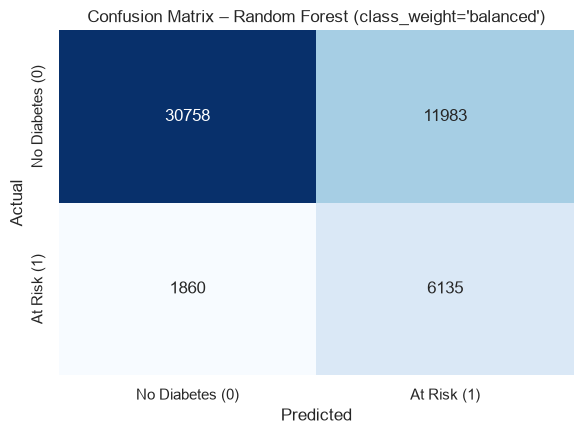


 XGBoost (scale_pos_weight)
              precision    recall  f1-score   support

           0     0.9443    0.7153    0.8140     42741
           1     0.3373    0.7746    0.4700      7995

    accuracy                         0.7247     50736
   macro avg     0.6408    0.7450    0.6420     50736
weighted avg     0.8487    0.7247    0.7598     50736

ROC-AUC : 0.8223


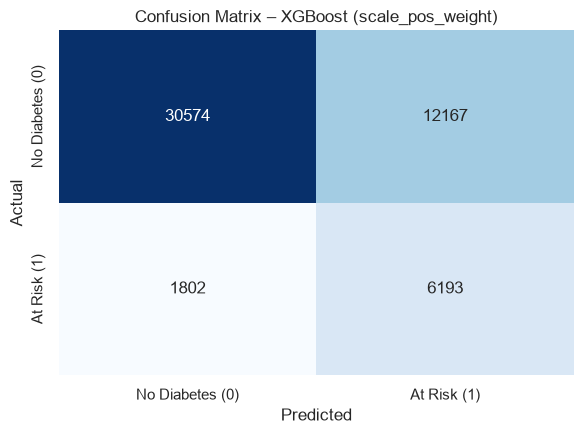

In [4]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*60}")
    print(f" {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, digits=4))
    
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC : {roc_auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No Diabetes (0)", "At Risk (1)"],
                yticklabels=["No Diabetes (0)", "At Risk (1)"])
    plt.title(f"Confusion Matrix – {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return {
        "model_name": model_name,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc,
        "y_proba": y_proba
    }

results_rf  = evaluate_model(rf,  X_test, y_test, "Random Forest (class_weight='balanced')")
results_xgb = evaluate_model(xgb, X_test, y_test, "XGBoost (scale_pos_weight)")

In [5]:
# Logistic Regression results from Day 4 (hard-coded from your previous run)
results_lr = {
    "model_name": "Logistic Regression (class_weight)",
    "precision": 0.3408,
    "recall": 0.7601,
    "f1": 0.4706,
    "roc_auc": 0.8176
}

comparison = pd.DataFrame([
    results_lr,
    {
        "model_name": "Random Forest",
        "precision": results_rf["precision"],
        "recall": results_rf["recall"],
        "f1": results_rf["f1"],
        "roc_auc": results_rf["roc_auc"]
    },
    {
        "model_name": "XGBoost",
        "precision": results_xgb["precision"],
        "recall": results_xgb["recall"],
        "f1": results_xgb["f1"],
        "roc_auc": results_xgb["roc_auc"]
    }
])

print("\n=== Final Model Comparison ===")
print(comparison.round(4).to_string(index=False))


=== Final Model Comparison ===
                        model_name  precision  recall     f1  roc_auc
Logistic Regression (class_weight)     0.3408  0.7601 0.4706   0.8176
                     Random Forest     0.3386  0.7674 0.4699   0.8223
                           XGBoost     0.3373  0.7746 0.4700   0.8223


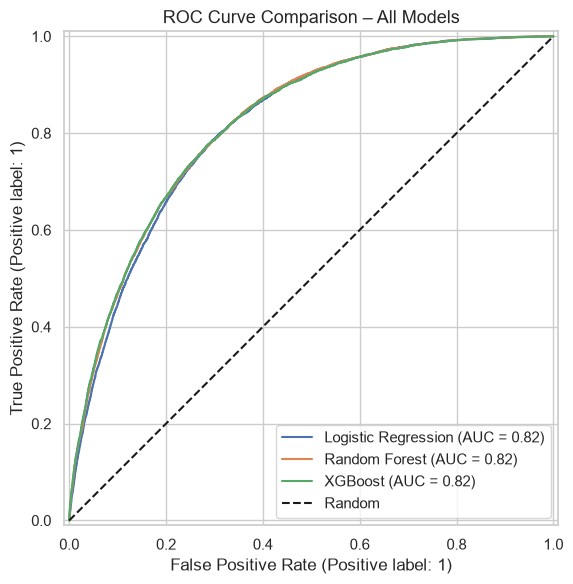

In [6]:
# We need the logistic regression probabilities again for a fair plot
# Re-train quickly or load if you saved it. For simplicity we re-train:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)
lr_proba = lr.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))

RocCurveDisplay.from_predictions(y_test, lr_proba, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, results_rf["y_proba"], name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(y_test, results_xgb["y_proba"], name="XGBoost", ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_title("ROC Curve Comparison – All Models", fontsize=13)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

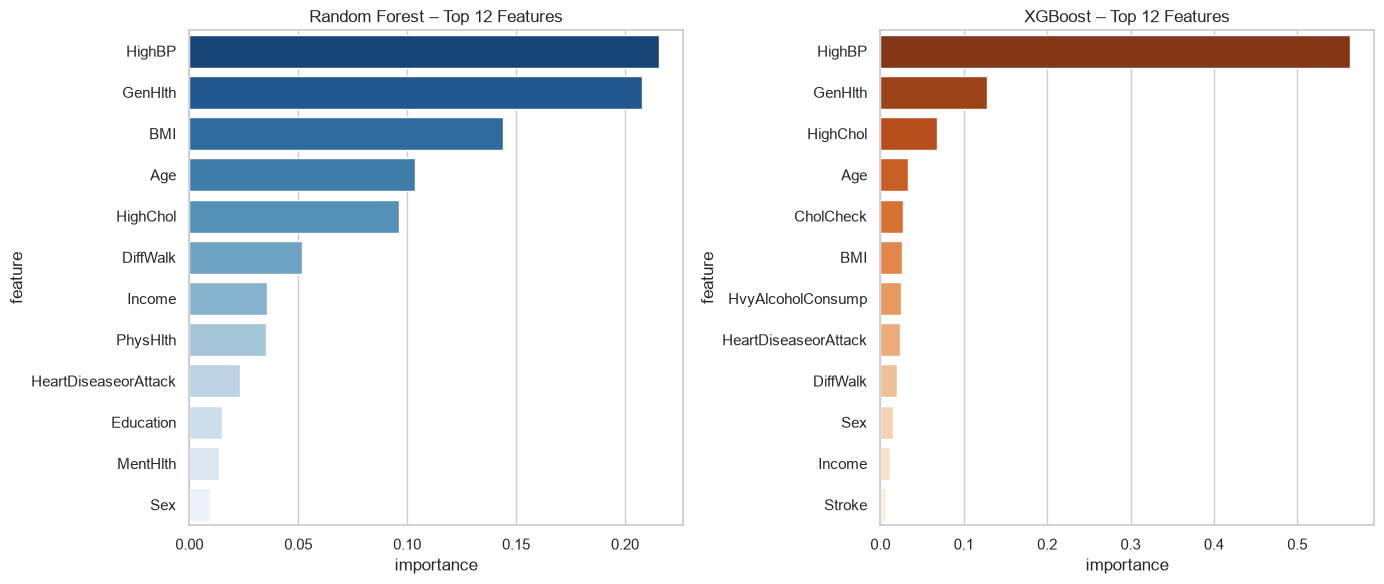

In [7]:
# Random Forest importance
rf_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

# XGBoost importance
xgb_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=rf_imp.head(12), x="importance", y="feature", ax=axes[0], palette="Blues_r")
axes[0].set_title("Random Forest – Top 12 Features")

sns.barplot(data=xgb_imp.head(12), x="importance", y="feature", ax=axes[1], palette="Oranges_r")
axes[1].set_title("XGBoost – Top 12 Features")

plt.tight_layout()
plt.show()

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, class_weight="balanced", random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, 
                             scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, eval_metric="logloss")
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)
    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std": scores.std()
    })
    print(f"{name:25s} → ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results)
print("\n", cv_df.round(4))

Logistic Regression       → ROC-AUC: 0.8177 ± 0.0023
Random Forest             → ROC-AUC: 0.8222 ± 0.0017
XGBoost                   → ROC-AUC: 0.8224 ± 0.0023

                  Model  Mean ROC-AUC    Std
0  Logistic Regression        0.8177 0.0023
1        Random Forest        0.8222 0.0017
2              XGBoost        0.8224 0.0023
